
<center>
<h1><b></b></h1>
<h1><b>CSC-272 - DATA MINING</b></h1>
<h1><b>FALL 2023</b></h1>
<h1><b>FINAL EXAM</b></h1>
</center>
<br/>
<hr/>
<br/>



**_Instructions_**:

* Make sure you _Save your Copy in Drive_ so you can edit and save.

* Make sure you add your first name to the filename.

* Submission format and instructions are same as the Programming Assignments.

* **Using loops only where absolutely necessary.**

* **Using loops where you could've used a vectorized operation covered in class would result in deduction of points.**

* **Feel free to use `sklearn` in your answers.**

* Use of any AI assistant during the Final would be considered plagiarism and result in an F in the course. 

* Use of any website or online resource during the Final would be considered plagiarism and result in an F in the course. 

<br/>
<hr/>
<br/>
<br/>
<center><h1><b>VIDEO GAME INDUSTRY</b></h1></center>
<br/>
The video game industry is one of the most profitable in the world. 

In recent years, it has surpassed the movie and music industries in terms of revenue.
<br/>
<br/>

<center><img width="75%" src="https://i.chzbgr.com/full/8017385984/hAF01869F/nintendos-new-mario-game"></center>

<center><img width="50%" src="https://i.imgur.com/0Y5Ggy4.jpeg"></center>

<br/>

Here you are given a dataset of video games and their sales in different regions of the world. The dataset contains the following columns:

* `Name`: Name of the game

* `Platform`: Platform on which the game was released (PC, PS4, XBOX, etc.)

* `Year`: Year of release

* `Genre`: Genre of the game

* `Publisher`: Publisher of the game

* `NA_Sales`: Sales in North America (in millions)

* `EU_Sales`: Sales in Europe (in millions)

* `JP_Sales`: Sales in Japan (in millions)

* `Other_Sales`: Sales in the rest of the world (in millions)

* `Global_Sales`: Total worldwide sales.

<br/>
<hr/>
<br/>

In [127]:
from matplotlib import pyplot as plt 
import pandas as pd
import seaborn as sns

data = pd.read_csv('data/vgsales.csv', index_col=0)

<br/>
<hr/>
<br/>

# **Question 1.** 

### **1.1.** Print first 4 rows of the dataframe



In [118]:
data.head(4)

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
Rank,,,,,,,,,,
1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00



### **1.2.** Print the number of  rows and columns in `data`.


In [5]:
data.shape

(16598, 10)

### **1.3.** Print the data type of each column

<br/>
<hr/>
<br/>

# **Question 2.**

### **2.1**. For each column in `data`, compute the percentage of rows that have missing values?

In [6]:
x = (data.isna().sum() * 100 / len(data))
x.sort_values()

Name            0.000000
Platform        0.000000
Genre           0.000000
NA_Sales        0.000000
EU_Sales        0.000000
JP_Sales        0.000000
Other_Sales     0.000000
Global_Sales    0.000000
Publisher       0.349440
Year            1.632727
dtype: float64

### **2.2.** Drop all rows with missing values in `data`

In [157]:
data = data.dropna()

<br/>
<hr/>
<br/>

#  **Question 3.** 

### **3.1.** Compute the number of unique values for each categorical variable in the data


In [11]:
data[['Platform', 'Genre', 'Publisher']].apply(lambda x: len(x.unique()))

Platform      31
Genre         12
Publisher    576
dtype: int64

<br/>

### **3.2.** For categorical variables with more than 50 unique values, **print** the frequency distribution of the variable. 

In [18]:
data['Publisher'].value_counts()

Electronic Arts                 1339
Activision                       966
Namco Bandai Games               928
Ubisoft                          918
Konami Digital Entertainment     823
                                ... 
Detn8 Games                        1
Pow                                1
Navarre Corp                       1
MediaQuest                         1
UIG Entertainment                  1
Name: Publisher, Length: 576, dtype: int64

<br/>

### **3.3.** For each categorical variable with less than 50 unique values, plot the distribution of the variable, using a bar chart.

Consider a horizontal bar chart, to improve readability, with the variable values on the y-axis and the frequency of each value on the x-axis.

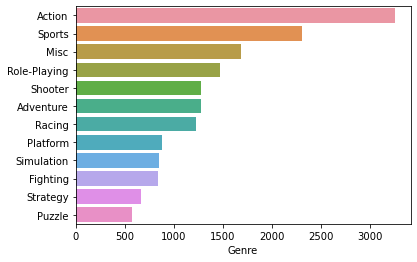

In [22]:
sns.barplot(y=data['Genre'].value_counts().index, x=data['Genre'].value_counts());

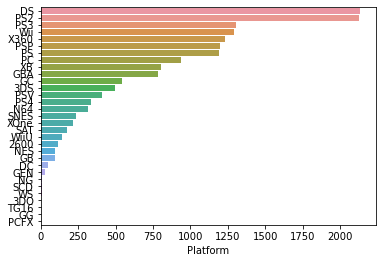

In [23]:
sns.barplot(y=data['Platform'].value_counts().index, x=data['Platform'].value_counts());

### **3.4.** For each numerical variable, plot the distribution of the variable, using a histogram.

Use **log scale** for y-axis of variables with **highly skewed distributions**.

Make sure each plot has a title. 

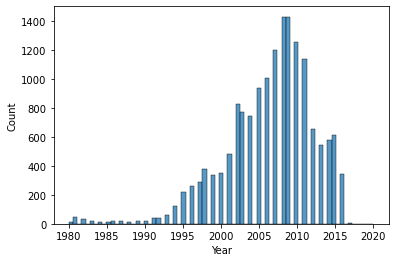

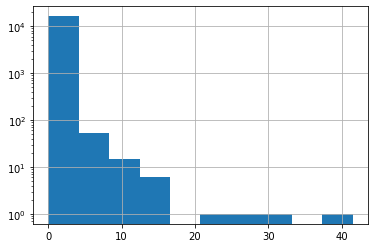

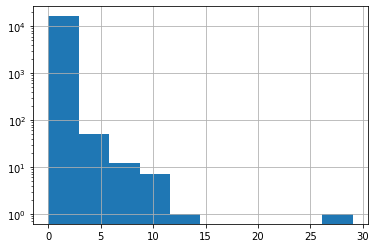

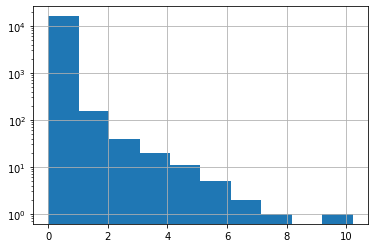

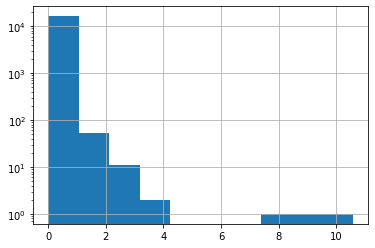

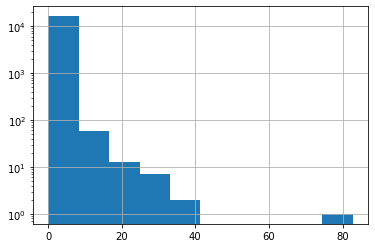

In [36]:


sns.histplot(data=data, x='Year');
plt.figure()
data['NA_Sales'].hist(log=True);
plt.figure()
data['EU_Sales'].hist(log=True);
plt.figure()
data['JP_Sales'].hist(log=True);
plt.figure()
data['Other_Sales'].hist(log=True);
plt.figure()
data['Global_Sales'].hist(log=True);

<br/>
<hr/>
<br/>

#  **Question 4.** 

<br/>

### 4.1. Identify top 3 games with the highest `Global_Sales`

In [43]:
data.sort_values(by='Global_Sales', ascending=False).head(3)

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
Rank,,,,,,,,,,
1,Wii Sports,Wii,2006.0,Sports,Nintendo,50.15,35.07,4.56,10.22,82.74
2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,72.27,8.90,16.92,1.91,40.24
3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,44.25,35.96,10.58,9.24,35.82


<br/>

### 4.2. Identify top 3 genres with the highest `Global_Sales`

In [126]:
data.groupby('Genre').sum()['Global_Sales'].sort_values(ascending=False)[:3]

Genre
Action     1751.18
Sports     1330.93
Shooter    1037.37
Name: Global_Sales, dtype: float64

<br/>

### 4.3. Identify top 3 platforms in North America with respect to sales in the region

In [125]:
data.groupby('Platform').sum()['Global_Sales'].sort_values(ascending=False)[:3]

Platform
PS2     1255.64
X360     979.96
PS3      957.84
Name: Global_Sales, dtype: float64

<br>
<hr>
<br>

#  **Question 5.** 

Create a new dataframe containing only the games with **more sales in Japan than in North America**.

In [46]:
data[data['JP_Sales'] > data['NA_Sales']]

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
Rank,,,,,,,,,,
27,Pokemon Black/Pokemon White,DS,2010.0,Role-Playing,Nintendo,36.36,21.41,36.88,5.35,15.32
28,Brain Age 2: More Training in Minutes a Day,DS,2005.0,Puzzle,Nintendo,22.48,35.03,34.77,7.71,15.30
42,Animal Crossing: Wild World,DS,2005.0,Simulation,Nintendo,20.78,28.69,43.44,7.17,12.27
67,Final Fantasy VII,PS,1997.0,Role-Playing,Sony Computer Entertainment,30.97,25.41,33.74,9.88,9.72
74,Animal Crossing: New Leaf,3DS,2012.0,Simulation,Nintendo,22.11,25.52,47.96,4.51,9.09
...,...,...,...,...,...,...,...,...,...,...
16578,Neo Angelique Special,PSP,2008.0,Adventure,Tecmo Koei,0.00,0.00,100.00,0.00,0.01
16583,Real Rode,PS2,2008.0,Adventure,Kadokawa Shoten,0.00,0.00,100.00,0.00,0.01
16590,Mezase!! Tsuri Master DS,DS,2009.0,Sports,Hudson Soft,0.00,0.00,100.00,0.00,0.01


<br/>
<hr/>
<br/>

#  **Question 6.** 

### **6.1.** Plot the number of Action and Role-Playing games released each year from 1990 to 2000.

The two genres should be plotted on the same plot as two separate lines, with different colors.

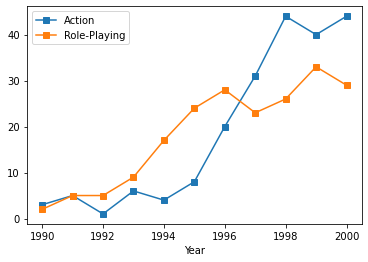

In [148]:
# plt.figure(figsize=(10, 5))

filtered = data[data['Year'].apply(lambda x: (x >= 1990) and (x <= 2000))]

action = filtered[filtered['Genre'] == 'Action']
sports = filtered[filtered['Genre'] == 'Role-Playing']



# filtered2 = filtered[filtered['Genre'].apply(lambda x: x in ['Action', 'Sports'])]

# counts = filtered2.groupby(['Genre', 'Year']).size().reset_index(name='counts')

# counts.groupby('Genre').apply(lambda x: plt.plot(x.sort_values(by='Year')['counts'].values, label=x['Genre'].values[0], marker='s'));
# plt.legend();
action.groupby('Year').size().plot(label='Action', marker='s');
sports.groupby('Year').size().plot(label='Role-Playing', marker='s');
plt.legend();

### **6.2.** Plot total sales in North America and Japan for each year between 1990 to 2000.

Plot the two variables on the same plot as two separate lines, with different colors.

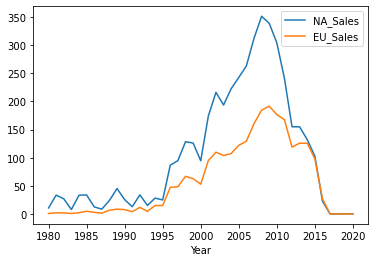

In [152]:
data.groupby(['Year']).sum()[['NA_Sales', 'EU_Sales']].plot();

### **6.3.** Make a scatter plot of `NA_Sales` vs `EU_Sales` for all games. Use `Genre` to color the points.

Use log scale for both axes.

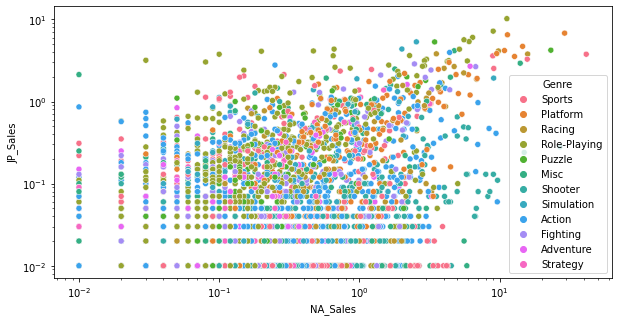

In [154]:
from matplotlib import pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.scatterplot(data=data, x='NA_Sales', y='JP_Sales', hue='Genre');

plt.xscale('log')
plt.yscale('log')


<br/>
<hr/>
<br/>

#  **Question 7.** 

### **7.1.** Compute percentage of sales

For each game in the data set, compute what percentage of the Global Sales are from North America, Europe, Japan, and the rest of the world.

For example, 

$$\text{North America\ Sales \%} = \frac{\text{NA\_Sales}}{\text{Global\_Sales}}$$

Similarly, for the other three columns, replace `NA_Sales` with the corresponding column name.

Create a new dataframe with these percentages. Do not change the original column values.

In [ ]:
pcts = data[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].apply(lambda x: x*100 / data['Global_Sales']).round(2)

pcts.head()

,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Rank,,,,
1,50.15,35.07,4.56,10.22
2,72.27,8.90,16.92,1.91
3,44.25,35.96,10.58,9.24
4,47.73,33.36,9.94,8.97
5,35.93,28.34,32.58,3.19


### **7.2.** Compute Decade

For each game in the data set, create a new column `decade` in which it was released. For example, if a game was released in 2007, its decade is 2000. 

$$ \text{Decade} = int(\frac{\text{Year}}{10}) * 10$$ 

where $int$ is type casting/conversion to `int` in Python. 

In [139]:
data['Year'] % 10

Rank
1        6.0
2        5.0
3        8.0
4        9.0
5        6.0
        ... 
16596    2.0
16597    3.0
16598    8.0
16599    0.0
16600    3.0
Name: Year, Length: 16598, dtype: float64

<br/>
<hr/>
<br/>

# **Question 8**.


### **8.1.** Compute $P(\text{Genre})$

In [128]:
p_type = data['Genre'].value_counts() / len(data)
p_type

Action          0.199783
Sports          0.141342
Misc            0.104772
Role-Playing    0.089649
Shooter         0.078925
Adventure       0.077479
Racing          0.075250
Platform        0.053380
Simulation      0.052235
Fighting        0.051090
Strategy        0.041029
Puzzle          0.035064
Name: Genre, dtype: float64

<br/>

### **8.2.** Compute $P(\text{Genre} | \text{Year} = 1989)$



In [131]:
filtered = data[data['Year']==1989]
filtered['Genre'].value_counts()/len(filtered)

Puzzle          0.294118
Platform        0.176471
Sports          0.176471
Action          0.117647
Role-Playing    0.117647
Misc            0.058824
Shooter         0.058824
Name: Genre, dtype: float64

<br/>

### **8.3.** Compute **$~~\underset{\text{Year}}{\textbf{arg max}}~~P(\text{Genre} = \text{Role-Playing} | \text{Year})$**



<br/>
<hr/>
<br/>

# **Question 9.** 



### Predict `NA_sales` from `JP_Sales` columns for video games.

Use all relevant evaluation metrics to assess your predictions

In [109]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

model = LinearRegression()

col_x = 'NA_Sales'
col_y = 'JP_Sales'

X = data[[col_x]]

y = data[col_y]

X_train, X_test, y_train, y_test = train_test_split(X, y)

model.fit(X_train, y_train)

preds = model.predict(X_test)

mae  = mean_absolute_error(y_test, preds)
mse  = mean_squared_error(y_test, preds, squared=False)
rmse = mean_squared_error(y_test, preds, squared=True)
r2   = r2_score(y_test, preds)

print(mae)
print(mse)
print(rmse)
print(r2)

0.11263737837402217
0.3045139865610759
0.09272876801131914
0.19412709878221823



<br/>
<hr/>
<br/>

# **Question 10.** 

Predict `Genre` from `NA_Sales`, `EU_Sales`, `JP_Sales`, `Other_Sales` columns.


In [107]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X = data[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']]
y = data['Genre']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

nn = KNeighborsClassifier()

nn.fit(X_train, y_train)

preds = nn.predict(X_test)

Evaluate your model using all relevant metrics. Report these metrics for each item `type`.

In [108]:
from sklearn.metrics import classification_report

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

      Action       0.23      0.45      0.31       852
   Adventure       0.21      0.30      0.25       324
    Fighting       0.08      0.09      0.08       201
        Misc       0.18      0.15      0.16       425
    Platform       0.10      0.04      0.06       206
      Puzzle       0.09      0.04      0.06       137
      Racing       0.13      0.07      0.09       319
Role-Playing       0.25      0.16      0.20       358
     Shooter       0.17      0.09      0.12       345
  Simulation       0.09      0.09      0.09       221
      Sports       0.26      0.19      0.22       598
    Strategy       0.14      0.04      0.06       164

    accuracy                           0.20      4150
   macro avg       0.16      0.14      0.14      4150
weighted avg       0.19      0.20      0.18      4150



Are your predictions better than random? 

<br>
<hr/>